# Evaluating on Test split

```
scp -J <username>@<server> <username>@<server>:/space/partner/nrcan/geobase/work/oatt/dev/semanticsearch/results/finetune_via_trainer/summary-2026_08_11_on_test.csv ./summary-2026_08_11_on_test.csv  
```

In [1]:
import pandas as pd

In [6]:
!pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np

In [8]:
df = pd.read_csv("summary-2026_08_11_on_test.csv")
df

,level_0,Unnamed: 0,index,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,...,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model
0,0,0,0,0.348980,0.520408,0.569388,0.644898,0.348980,0.173469,0.113878,...,0.520408,0.569388,0.644898,0.493315,0.445242,0.452124,en,text_en,baseline,gte-multilingual-base
1,1,1,0,0.230612,0.385714,0.457143,0.526531,0.230612,0.128571,0.091429,...,0.385714,0.457143,0.526531,0.372366,0.323567,0.332417,fr,text_en,baseline,gte-multilingual-base
2,2,2,0,0.322449,0.500000,0.565306,0.632653,0.322449,0.166667,0.113061,...,0.500000,0.565306,0.632653,0.471376,0.420197,0.427405,en,text_seq,baseline,gte-multilingual-base
3,3,3,0,0.251020,0.404082,0.471429,0.557143,0.251020,0.134694,0.094286,...,0.404082,0.471429,0.557143,0.395461,0.344934,0.352566,fr,text_seq,baseline,gte-multilingual-base
4,4,4,0,0.316327,0.487755,0.540816,0.644898,0.316327,0.162585,0.108163,...,0.487755,0.540816,0.644898,0.471335,0.417086,0.422901,en,text_para,baseline,gte-multilingual-base
5,5,5,0,0.259184,0.412245,0.491837,0.563265,0.259184,0.137415,0.098367,...,0.412245,0.491837,0.563265,0.404267,0.354065,0.361032,fr,text_para,baseline,gte-multilingual-base
6,6,0,0,0.406122,0.579592,0.628571,0.700000,0.406122,0.193197,0.125714,...,0.579592,0.628571,0.700000,0.550631,0.503235,0.509486,en,text_en,finetune-mnrl-mix-seq-sq512,gte-multilingual-base
7,7,1,0,0.316327,0.479592,0.544898,0.630612,0.316327,0.159864,0.108980,...,0.479592,0.544898,0.630612,0.467463,0.416164,0.422781,fr,text_en,finetune-mnrl-mix-seq-sq512,gte-multilingual-base
8,8,2,0,0.406122,0.561224,0.632653,0.706122,0.406122,0.187075,0.126531,...,0.561224,0.632653,0.706122,0.549811,0.500556,0.506335,en,text_seq,finetune-mnrl-mix-seq-sq512,gte-multilingual-base
9,9,3,0,0.371429,0.526531,0.575510,0.651020,0.371429,0.175510,0.115102,...,0.526531,0.575510,0.651020,0.507229,0.461729,0.468041,fr,text_seq,finetune-mnrl-mix-seq-sq512,gte-multilingual-base


In [9]:
df = df.drop(columns=["level_0", "Unnamed: 0", "index"])
df.shape

(24, 19)

In [10]:
df.head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model
0,0.348980,0.520408,0.569388,0.644898,0.348980,0.173469,0.113878,0.064490,0.348980,0.520408,0.569388,0.644898,0.493315,0.445242,0.452124,en,text_en,baseline,gte-multilingual-base
1,0.230612,0.385714,0.457143,0.526531,0.230612,0.128571,0.091429,0.052653,0.230612,0.385714,0.457143,0.526531,0.372366,0.323567,0.332417,fr,text_en,baseline,gte-multilingual-base
2,0.322449,0.500000,0.565306,0.632653,0.322449,0.166667,0.113061,0.063265,0.322449,0.500000,0.565306,0.632653,0.471376,0.420197,0.427405,en,text_seq,baseline,gte-multilingual-base
3,0.251020,0.404082,0.471429,0.557143,0.251020,0.134694,0.094286,0.055714,0.251020,0.404082,0.471429,0.557143,0.395461,0.344934,0.352566,fr,text_seq,baseline,gte-multilingual-base
4,0.316327,0.487755,0.540816,0.644898,0.316327,0.162585,0.108163,0.064490,0.316327,0.487755,0.540816,0.644898,0.471335,0.417086,0.422901,en,text_para,baseline,gte-multilingual-base


In [11]:
df["full_name"] = df["model"] +"-"+ df["document_repr"]+ "-"+ df["config"]
df.head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
0,0.348980,0.520408,0.569388,0.644898,0.348980,0.173469,0.113878,0.064490,0.348980,0.520408,0.569388,0.644898,0.493315,0.445242,0.452124,en,text_en,baseline,gte-multilingual-base,gte-multilingual-base-text_en-baseline
1,0.230612,0.385714,0.457143,0.526531,0.230612,0.128571,0.091429,0.052653,0.230612,0.385714,0.457143,0.526531,0.372366,0.323567,0.332417,fr,text_en,baseline,gte-multilingual-base,gte-multilingual-base-text_en-baseline
2,0.322449,0.500000,0.565306,0.632653,0.322449,0.166667,0.113061,0.063265,0.322449,0.500000,0.565306,0.632653,0.471376,0.420197,0.427405,en,text_seq,baseline,gte-multilingual-base,gte-multilingual-base-text_seq-baseline
3,0.251020,0.404082,0.471429,0.557143,0.251020,0.134694,0.094286,0.055714,0.251020,0.404082,0.471429,0.557143,0.395461,0.344934,0.352566,fr,text_seq,baseline,gte-multilingual-base,gte-multilingual-base-text_seq-baseline
4,0.316327,0.487755,0.540816,0.644898,0.316327,0.162585,0.108163,0.064490,0.316327,0.487755,0.540816,0.644898,0.471335,0.417086,0.422901,en,text_para,baseline,gte-multilingual-base,gte-multilingual-base-text_para-baseline


In [12]:
# best model for pure EN performance
subset_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en")]
subset_df.sort_values(by="cosine_recall@3", ascending=False).head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
6,0.406122,0.579592,0.628571,0.700000,0.406122,0.193197,0.125714,0.070000,0.406122,0.579592,0.628571,0.700000,0.550631,0.503235,0.509486,en,text_en,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-mi...
18,0.369485,0.536765,0.590074,0.650735,0.369485,0.178922,0.118015,0.065074,0.369485,0.536765,0.590074,0.650735,0.508133,0.462603,0.468391,en,text_en,2026_08_11/finetune-hn-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_en-2026_08_11/finet...
12,0.373162,0.529412,0.586397,0.652574,0.373162,0.176471,0.117279,0.065257,0.373162,0.529412,0.586397,0.652574,0.509199,0.463583,0.469549,en,text_en,2026_08_11/finetune-mnrl-mix-seq-sq1024,gte-multilingual-base,gte-multilingual-base-text_en-2026_08_11/finet...
0,0.348980,0.520408,0.569388,0.644898,0.348980,0.173469,0.113878,0.064490,0.348980,0.520408,0.569388,0.644898,0.493315,0.445242,0.452124,en,text_en,baseline,gte-multilingual-base,gte-multilingual-base-text_en-baseline


In [13]:
# best model for FR performance
subset_df = df[(df["document_repr"]=="text_seq") & 
               (df["lang"]=="fr")]
subset_df.sort_values(by="cosine_recall@3", ascending=False).head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
9,0.371429,0.526531,0.575510,0.651020,0.371429,0.175510,0.115102,0.065102,0.371429,0.526531,0.575510,0.651020,0.507229,0.461729,0.468041,fr,text_seq,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_seq-finetune-mnrl-m...
15,0.369485,0.522059,0.575368,0.623162,0.369485,0.174020,0.115074,0.062316,0.369485,0.522059,0.575368,0.623162,0.496944,0.456351,0.462771,fr,text_seq,2026_08_11/finetune-mnrl-mix-seq-sq1024,gte-multilingual-base,gte-multilingual-base-text_seq-2026_08_11/fine...
21,0.354779,0.518382,0.564338,0.604779,0.354779,0.172794,0.112868,0.060478,0.354779,0.518382,0.564338,0.604779,0.482428,0.442765,0.450659,fr,text_seq,2026_08_11/finetune-hn-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_seq-2026_08_11/fine...
3,0.251020,0.404082,0.471429,0.557143,0.251020,0.134694,0.094286,0.055714,0.251020,0.404082,0.471429,0.557143,0.395461,0.344934,0.352566,fr,text_seq,baseline,gte-multilingual-base,gte-multilingual-base-text_seq-baseline


In [14]:
subset_df = df[(df["document_repr"]=="text_seq")]
subset_df['exp_name'] = subset_df['model'] + "/"+subset_df['config'] +"/"+ subset_df['document_repr']

df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)
df_pivot.sort_values(by="mean", ascending=False)

lang,en,fr,mean
exp_name,,,
gte-multilingual-base/finetune-mnrl-mix-seq-sq512/text_seq,0.561224,0.526531,0.543878
gte-multilingual-base/2026_08_11/finetune-hn-mnrl-mix-seq-sq512/text_seq,0.531250,0.518382,0.524816
gte-multilingual-base/2026_08_11/finetune-mnrl-mix-seq-sq1024/text_seq,0.518382,0.522059,0.520221
gte-multilingual-base/baseline/text_seq,0.500000,0.404082,0.452041


## Multilingual models
Objective: determine what multilingual model achieves best cross-lingual performance on FR-EN queries with variable document representation

In [15]:
# how well does finetuning on more specific queries or with hard negatives help/hinder cross-lingual performance?
multilingual_models = ["gte-multilingual-base"]

subset_df = df[(df["document_repr"]=="text_seq") &
               (df["model"].isin(multilingual_models)) &
               ((df["config"] == "baseline") | (df["config"].str.contains("mix-seq")))]

subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'baseline' if 'baseline' in x.lower() else '2026_08_11_hn' if '2026_08_11' in x.lower() and 'hn' in x.lower() else '2026_08_11' if '2026_08_11' in x.lower() else 'ft')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df[['model', 'model_short', 'lang', 'config', 'exp_name', 'document_repr', 'cosine_recall@3']]


,model,model_short,lang,config,exp_name,document_repr,cosine_recall@3
2,gte-multilingual-base,gte_multi,en,baseline,gte_multi_baseline,text_seq,0.500000
3,gte-multilingual-base,gte_multi,fr,baseline,gte_multi_baseline,text_seq,0.404082
8,gte-multilingual-base,gte_multi,en,finetune-mnrl-mix-seq-sq512,gte_multi_ft,text_seq,0.561224
9,gte-multilingual-base,gte_multi,fr,finetune-mnrl-mix-seq-sq512,gte_multi_ft,text_seq,0.526531
14,gte-multilingual-base,gte_multi,en,2026_08_11/finetune-mnrl-mix-seq-sq1024,gte_multi_2026_08_11,text_seq,0.518382
15,gte-multilingual-base,gte_multi,fr,2026_08_11/finetune-mnrl-mix-seq-sq1024,gte_multi_2026_08_11,text_seq,0.522059
20,gte-multilingual-base,gte_multi,en,2026_08_11/finetune-hn-mnrl-mix-seq-sq512,gte_multi_2026_08_11_hn,text_seq,0.531250
21,gte-multilingual-base,gte_multi,fr,2026_08_11/finetune-hn-mnrl-mix-seq-sq512,gte_multi_2026_08_11_hn,text_seq,0.518382


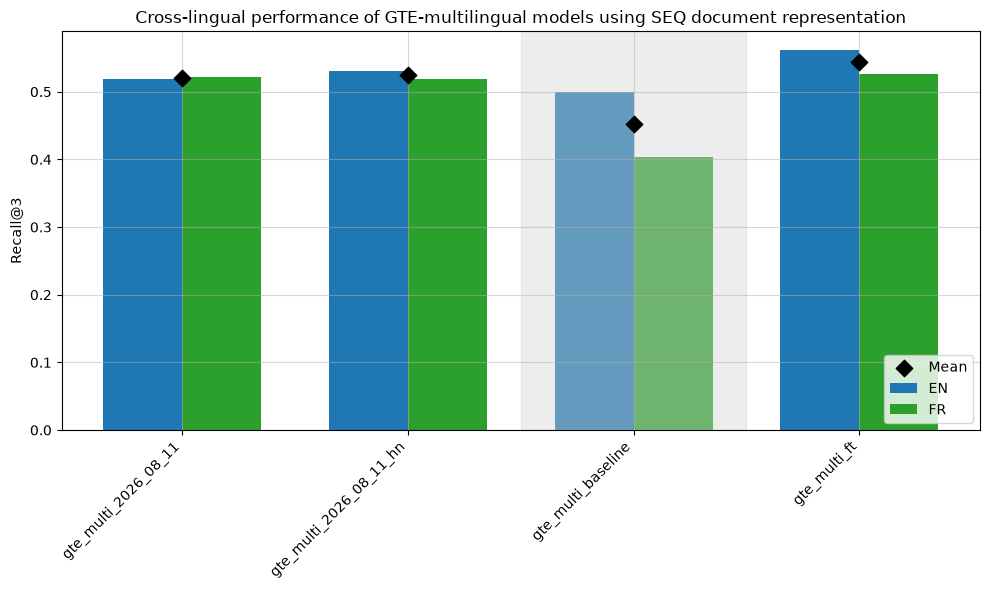

In [16]:
# Pivot
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='tab:blue')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='tab:green')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'baseline' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of GTE-multilingual models using SEQ document representation')
ax.set_ylabel('Recall@3')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


- EN and FR performance on updated-ft is closer than with the previous version
- Adding hard negatives helps improve mean performance compared to updated without hn, but also results in a higher discrepancy between the two languages, which is not as large as previous ft

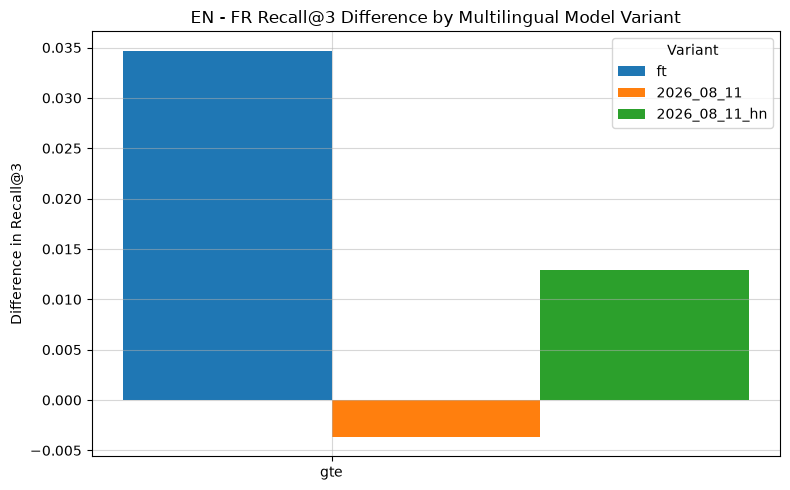

In [17]:
# Lets look into that "FT exhibit smaller discprepancy" statement a bit more clearly... graph the drop in difference
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot['recall_diff_en_fr'] = df_pivot['en'] - df_pivot['fr']
df_plot = df_pivot.reset_index()

parts = df_plot["exp_name"].str.split("_", expand=True)
df_plot["family"] = parts[0]
df_plot["variant"] = parts.iloc[:, 2:].fillna("").agg("_".join, axis=1).str.strip("_")

pivot_df = df_plot.pivot(
    index="family",
    columns="variant",
    values="recall_diff_en_fr"
)

families = pivot_df.index.tolist()
x = np.arange(len(families))
width = 0.35
variants = ["ft", "2026_08_11", "2026_08_11_hn"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, variant in enumerate(variants):
    ax.bar(
        x + i * width,
        pivot_df[variant],
        width,
        label=variant
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(families)

ax.set_ylabel("Difference in Recall@3")
ax.set_title("EN - FR Recall@3 Difference by Multilingual Model Variant")

ax.legend(title="Variant")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- Yes. The more specific queries help decrease cross-lingual discrepancy by at least 2-fold.
- Interestingly, without hard_negatives, EN queries actually perform ever so slightly less (or on par) with FR queries

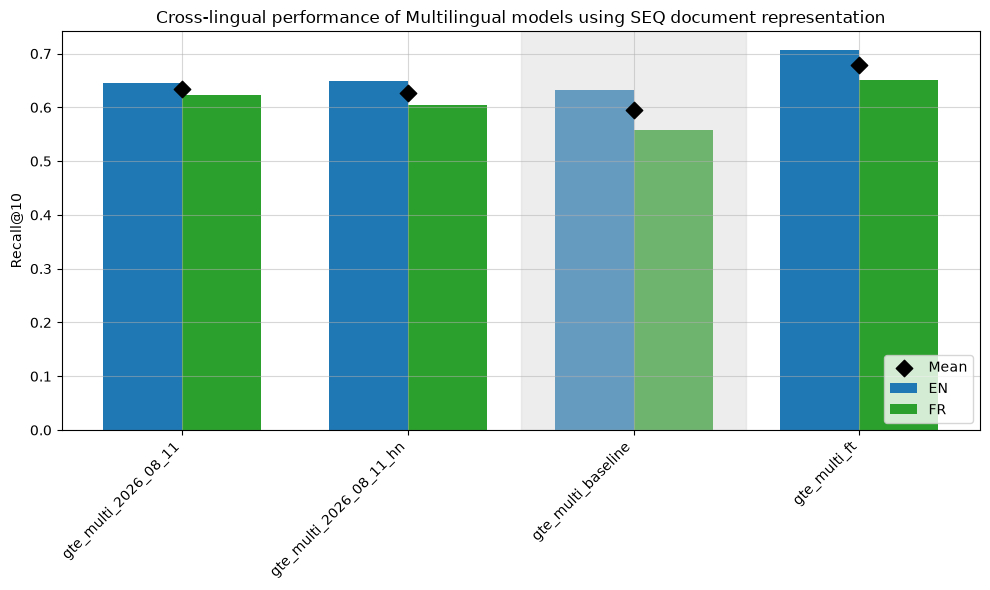

In [18]:
# can we have a look at overall retrieval capability i.e. recall@10 instead of 3
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@10')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='tab:blue')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='tab:green')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'baseline' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of Multilingual models using SEQ document representation')
ax.set_ylabel('Recall@10')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


- very similar trend to recall@3

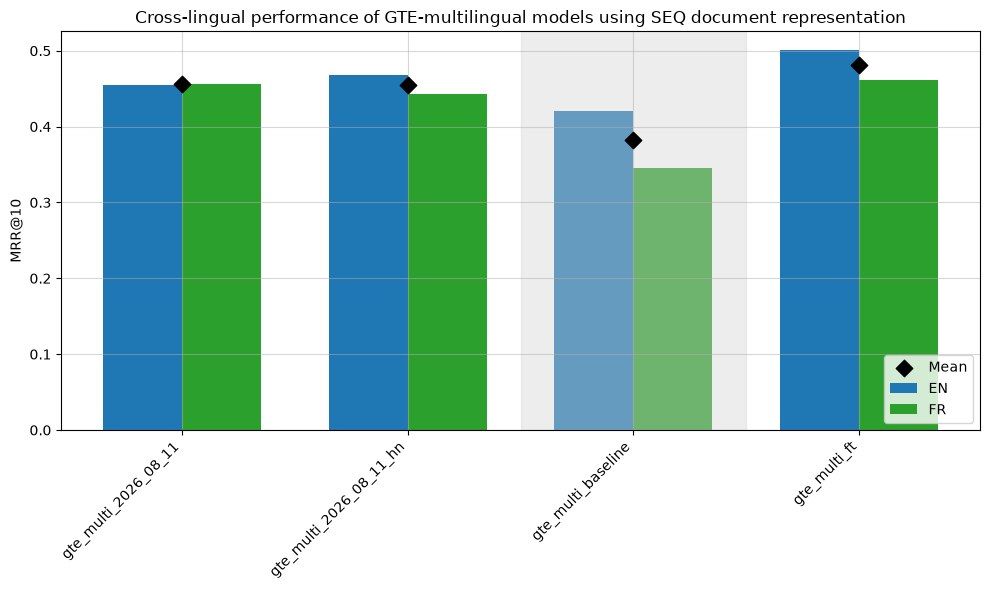

In [19]:
# can we have a look at ranking i.e. MRR@10
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_mrr@10')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='tab:blue')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='tab:green')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'baseline' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of GTE-multilingual models using SEQ document representation')
ax.set_ylabel('MRR@10')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


# Explore actual documents retrieved...

Files transferred from HPC:
- `survey` indicates file from `perf_on_benchmark/query2title_survey_results`
- lack of `survey` indicates file from evaluation on other benchmark (benchmark 1) 

Sample of command used:
```
scp -J <username>@<server> <username>@<server>:/space/partner/nrcan/geobase/work/oatt/dev/semanticsearch/results/finetune_via_trainer/gte-multilingual-base-baseline/2026_08_11/finetune-hn-mnrl-mix-seq-sq512/gte-multilingual-base/perf_on_benchmark/query2title_survey_results/Information-Retrieval_evaluation_gte-multilingual-base-finetuned-2026_08_11_hn_performance_on_benchmark_predictions_cosine.jsonl ./gte-2026-08-11-hn-finetuned-survey-results.jsonl
```

In [20]:
import json

In [21]:
# Load ft results

with open("gte-finetuned-survey-corpus.json") as f:
    gte_finetuned_survey_corpus_dict = json.load(f)

gte_finetuned_survey_results = pd.read_json('gte-finetuned-survey-results.jsonl', lines=True)
gte_finetuned_survey_results.head()

,query_id,query,results
0,0,no logging alberta,"[{'corpus_id': 4553, 'score': 0.46654069423675..."
1,1,élévation canada,"[{'corpus_id': 1, 'score': 0.6566305756568901}..."
2,2,tornado warnings,"[{'corpus_id': 22, 'score': 0.5757013559341431..."
3,3,Feux de forêt,"[{'corpus_id': 3, 'score': 0.6687901020050041}..."
4,4,endangered species,"[{'corpus_id': 8841, 'score': 0.62959653139114..."


In [22]:
def map_titles(results):
    return [
        {
            **item,
            "title_en": gte_finetuned_survey_corpus_dict.get(str(item["corpus_id"]))
        }
        for item in results
    ]

gte_finetuned_survey_results["results_with_titles"] = gte_finetuned_survey_results["results"].apply(map_titles)

In [23]:
# Load FT new results from 2026-08-11
with open("gte-finetuned-2026-08-11-survey-corpus.json") as f:
    gte_finetuned_new_survey_corpus_dict = json.load(f)

gte_finetuned_survey_results_new = pd.read_json('gte-2026-08-11-finetuned-survey-results.jsonl', lines=True)

def map_titles(results):
    return [
        {
            **item,
            "title_en": gte_finetuned_new_survey_corpus_dict.get(str(item["corpus_id"]))
        }
        for item in results
    ]

gte_finetuned_survey_results_new["results_with_titles"] = gte_finetuned_survey_results_new["results"].apply(map_titles)

In [24]:
# Load FT new results from 2026-08-11 with hard negatives
with open("gte-2026-08-11-hn-finetuned-survey-corpus.json") as f:
    gte_finetuned_new_hn_survey_corpus_dict = json.load(f)

gte_finetuned_hn_survey_results_new = pd.read_json('gte-2026-08-11-hn-finetuned-survey-results.jsonl', lines=True)

def map_titles(results):
    return [
        {
            **item,
            "title_en": gte_finetuned_new_hn_survey_corpus_dict.get(str(item["corpus_id"]))
        }
        for item in results
    ]

gte_finetuned_hn_survey_results_new["results_with_titles"] = gte_finetuned_hn_survey_results_new["results"].apply(map_titles)

In [25]:
# Query

i = 1

print(f"Query: {gte_finetuned_survey_results.iloc[i]['query']}")

Query: élévation canada


In [47]:
# FT Result

gte_finetuned_survey_results.iloc[i]['results_with_titles']

[{'corpus_id': 1,
  'score': 0.6566305756568901,
  'title_en': "Elevation in Canada - CanVec Series - Elevation Features\nkeywords:Canada, Earth Sciences, NTDB, CanVec, 1, 000, 000, 5, 000, 000, 15, 000, 000, 1M, 5M, 15M, 50K, 50, 000, 250K, 250, 000, Elevation, Contours, Elevation point, Spot height, Relief, Landscape, Hypsography, Geography, Geomatics\nThe elevation features of the CanVec series include the elevation contours and elevation points. These entities are used to describe the relief of the Canadian Landmass.\nThe CanVec multiscale series is available as prepackaged downloadable files and by user-defined extent via a Geospatial data extraction tool.\nRelated Products (Open Maps Links):\n[Topographic Data of Canada - CanVec Series](open.canada.ca [url])\nÉlévation au Canada - Série CanVec - Entités élévation\nmots-clés associés:Canada, Sciences de la Terre, BNDT, CanVec, 1 000 000, 5 000 000, 15 000 000, 1M, 5M, 15M, 50K, 50 000, 250K, 250 000, Élévation, Courbes de niveau, 

In [48]:
# FT New result
gte_finetuned_survey_results_new.iloc[i]['results_with_titles']

[{'corpus_id': 1,
  'score': 0.662943542003631,
  'title_en': "Elevation in Canada - CanVec Series - Elevation Features\nkeywords:Canada, Earth Sciences, NTDB, CanVec, 1, 000, 000, 5, 000, 000, 15, 000, 000, 1M, 5M, 15M, 50K, 50, 000, 250K, 250, 000, Elevation, Contours, Elevation point, Spot height, Relief, Landscape, Hypsography, Geography, Geomatics\nThe elevation features of the CanVec series include the elevation contours and elevation points. These entities are used to describe the relief of the Canadian Landmass.\nThe CanVec multiscale series is available as prepackaged downloadable files and by user-defined extent via a Geospatial data extraction tool.\nRelated Products (Open Maps Links):\n[Topographic Data of Canada - CanVec Series](open.canada.ca [url])\nÉlévation au Canada - Série CanVec - Entités élévation\nmots-clés associés:Canada, Sciences de la Terre, BNDT, CanVec, 1 000 000, 5 000 000, 15 000 000, 1M, 5M, 15M, 50K, 50 000, 250K, 250 000, Élévation, Courbes de niveau, P

In [49]:
#FT New result with hard negatives
gte_finetuned_hn_survey_results_new.iloc[i]['results_with_titles']

[{'corpus_id': 1,
  'score': 0.697084069252014,
  'title_en': "Elevation in Canada - CanVec Series - Elevation Features\nkeywords:Canada, Earth Sciences, NTDB, CanVec, 1, 000, 000, 5, 000, 000, 15, 000, 000, 1M, 5M, 15M, 50K, 50, 000, 250K, 250, 000, Elevation, Contours, Elevation point, Spot height, Relief, Landscape, Hypsography, Geography, Geomatics\nThe elevation features of the CanVec series include the elevation contours and elevation points. These entities are used to describe the relief of the Canadian Landmass.\nThe CanVec multiscale series is available as prepackaged downloadable files and by user-defined extent via a Geospatial data extraction tool.\nRelated Products (Open Maps Links):\n[Topographic Data of Canada - CanVec Series](open.canada.ca [url])\nÉlévation au Canada - Série CanVec - Entités élévation\nmots-clés associés:Canada, Sciences de la Terre, BNDT, CanVec, 1 000 000, 5 000 000, 15 000 000, 1M, 5M, 15M, 50K, 50 000, 250K, 250 000, Élévation, Courbes de niveau, P

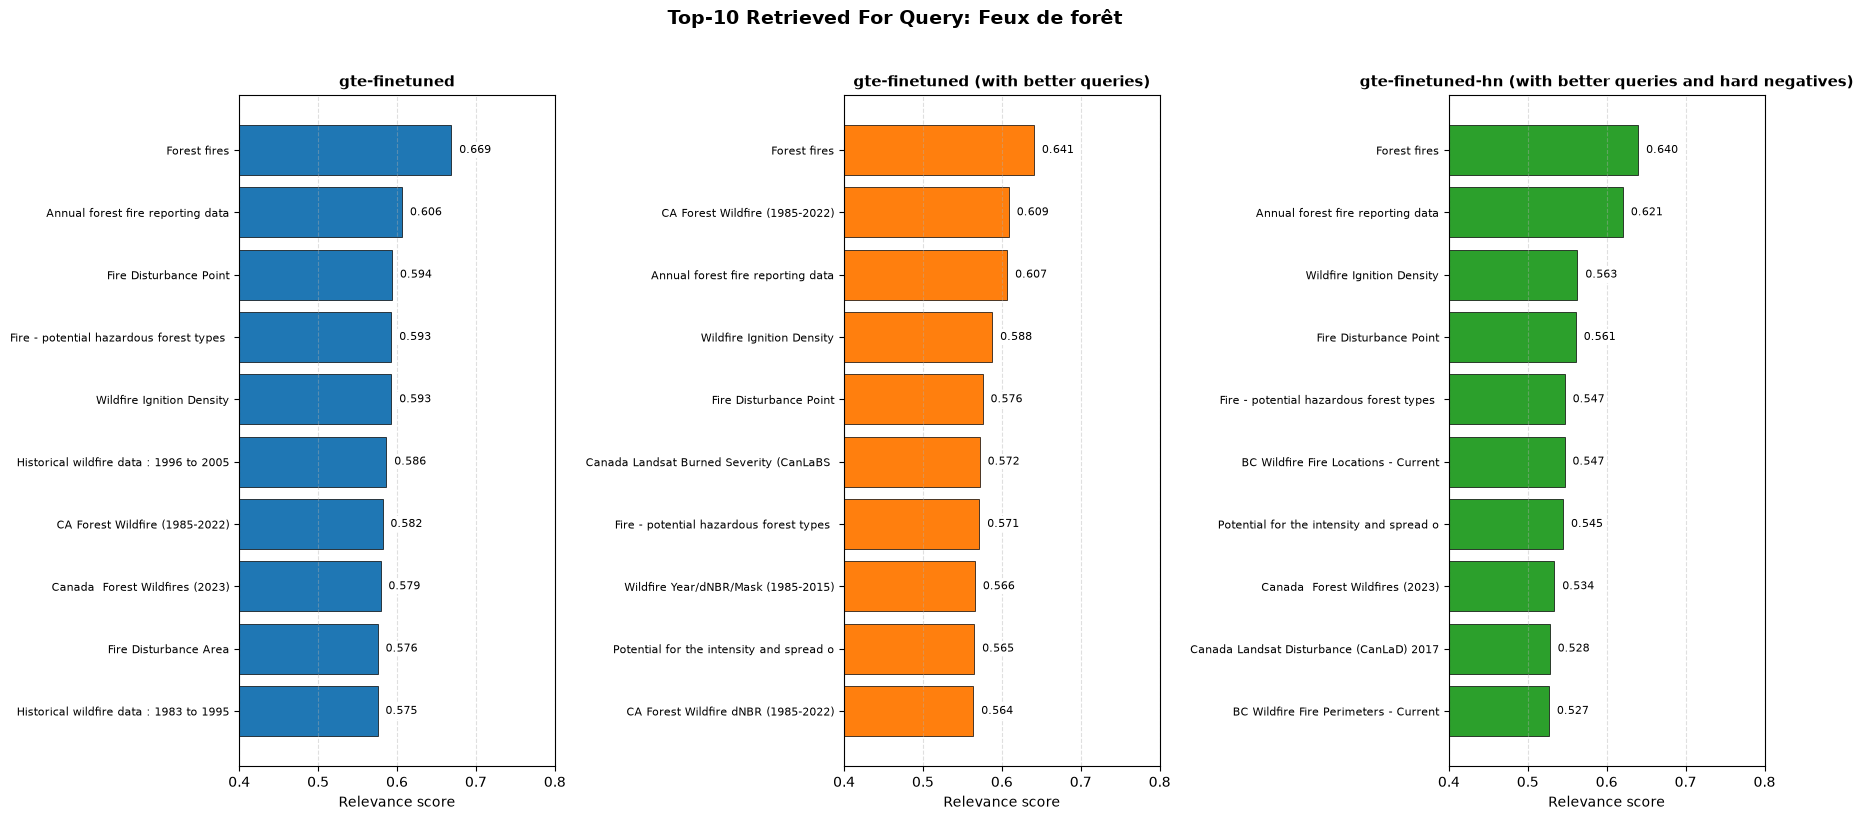

In [26]:
"""
Faceted horizontal bar chart comparing top-10 retrieval results
across 3 embedding models.

Assumes each dataframe has a column "results_with_titles" containing
a list of dicts like:
    {"corpus_id": ..., "score": ..., "title_en": "..."}
(only the first row's list is used, matching the structure shown in
the reference data — adjust the row selector if your results are
stored differently, e.g. one row per query).
"""

import matplotlib.pyplot as plt

plt.close('all')

# -----------------------------------------------------------------
# 1. Config: map a friendly model name -> its results dataframe
# -----------------------------------------------------------------
model_dataframes = {
    "gte-finetuned": gte_finetuned_survey_results,
    "gte-finetuned (with better queries)": gte_finetuned_survey_results_new,
    "gte-finetuned-hn (with better queries and hard negatives)": gte_finetuned_hn_survey_results_new,
}

TOP_N = 10
TITLE_MAX_CHARS = 40  # truncate title text to this many characters
ROW_INDEX = 3  # which row's "results_with_titles" list to use



def extract_top_results(df, row_index=ROW_INDEX, top_n=TOP_N):
    """Pull the top_n {title_en, score} pairs from results_with_titles."""
    records = df.iloc[row_index]["results_with_titles"]
    # sort by score descending, just in case they aren't pre-sorted
    records_sorted = sorted(records, key=lambda r: r["score"], reverse=True)[:top_n]
    titles = [r["title_en"].split("\n")[0] for r in records_sorted]  # first line only
    scores = [r["score"] for r in records_sorted]
 
    # sanity check: flag titles that collide after truncation
    seen = {}
    for t in titles:
        key = t[:TITLE_MAX_CHARS]
        seen[key] = seen.get(key, 0) + 1
    duplicates = [k for k, v in seen.items() if v > 1]
    if duplicates:
        print(f"Note: {len(duplicates)} title(s) collide after truncation, disambiguating: {duplicates}")
 
    # disambiguate: if truncated titles collide, append a counter suffix
    # so every bar stays visible instead of overlapping/being dropped
    counts = {}
    display_titles = []
    for t in titles:
        key = t[:TITLE_MAX_CHARS]
        counts[key] = counts.get(key, 0) + 1
        if counts[key] > 1:
            display_titles.append(f"{key} ({counts[key]})")
        else:
            display_titles.append(key)
 
    return display_titles, scores
 
 
def truncate_title(title, max_chars=TITLE_MAX_CHARS):
    return title if len(title) <= max_chars else title[:max_chars].rstrip() + "..."
 
 
# -----------------------------------------------------------------
# 2. Build the figure: one horizontal-bar panel per model
# -----------------------------------------------------------------
n_models = len(model_dataframes)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_models,
    figsize=(6 * n_models, 8),
    sharex=True,
)
 
colors = plt.cm.tab10.colors
 
for ax, (model_name, df), color in zip(axes, model_dataframes.items(), colors):
    titles, scores = extract_top_results(df)
 
    # reverse so highest score appears at the top of the barh chart
    titles = titles[::-1]
    scores = scores[::-1]
    # titles are already truncated (and disambiguated with a counter
    # suffix, e.g. "Some Title... (2)") inside extract_top_results
    bars = ax.barh(titles, scores, color=color, edgecolor="black", linewidth=0.5)
 
    # annotate each bar with its score
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}",
            va="center",
            fontsize=8,
            bbox=dict(
                facecolor="white",   # background color
                edgecolor="none",    # border color (set to "none" to remove)
                boxstyle="square,pad=0.2",
                alpha=1,           # transparency
            ),
        )
 
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Relevance score")
    ax.set_xlim(0.4, 0.8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle(f"Top-10 Retrieved For Query: {gte_finetuned_survey_results.iloc[ROW_INDEX]['query']}", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()

# -----------------------------------------------------------------
# 3. Save + show
# -----------------------------------------------------------------
# fig.savefig("model_comparison_top10.png", dpi=200, bbox_inches="tight")
plt.show()

- By manually exploring and comparing relevance scores, the version with the hard negatives exhibits more score collapse - documents are clustered a lot closer to each other (denser embedding clusters), causing different documents to be unintuitively shown with similar relevance.
- The updated-ft method (the one with more specific queries) seems to balance well between the two implementations - the scores "make more sense"